In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42


In [15]:
df = pd.read_csv("cs-training.csv")

# Drop stray index column some Kaggle exports include
if df.columns[0].lower() in ('unnamed: 0', 'id'):
    df = df.drop(columns=[df.columns[0]])

print(f"Shape: {df.shape}")
df.head()

Shape: (150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtype

In [17]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


In [18]:
print("Missing values per column:")
print(df.isnull().sum().sort_values(ascending=False))

Missing values per column:
MonthlyIncome                           29731
NumberOfDependents                       3924
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
dtype: int64


SeriousDlqin2yrs
0    93.316
1     6.684
Name: proportion, dtype: float64


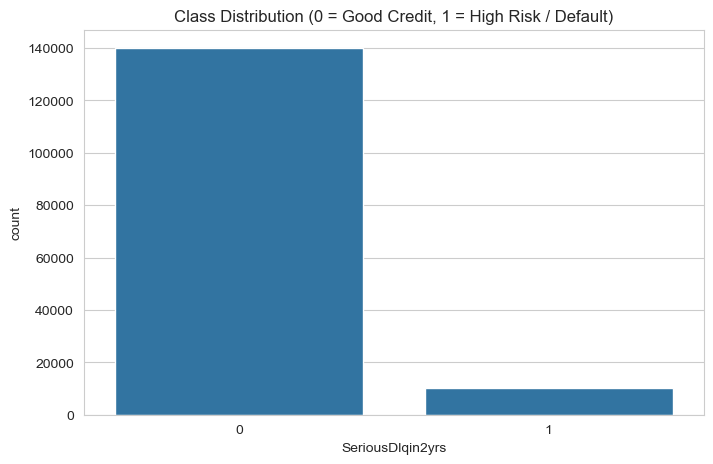

In [19]:
target_counts = df[TARGET_COL].value_counts(normalize=True) * 100
print(target_counts)

plt.figure()
sns.countplot(x=TARGET_COL, data=df)
plt.title('Class Distribution (0 = Good Credit, 1 = High Risk / Default)')
plt.show()

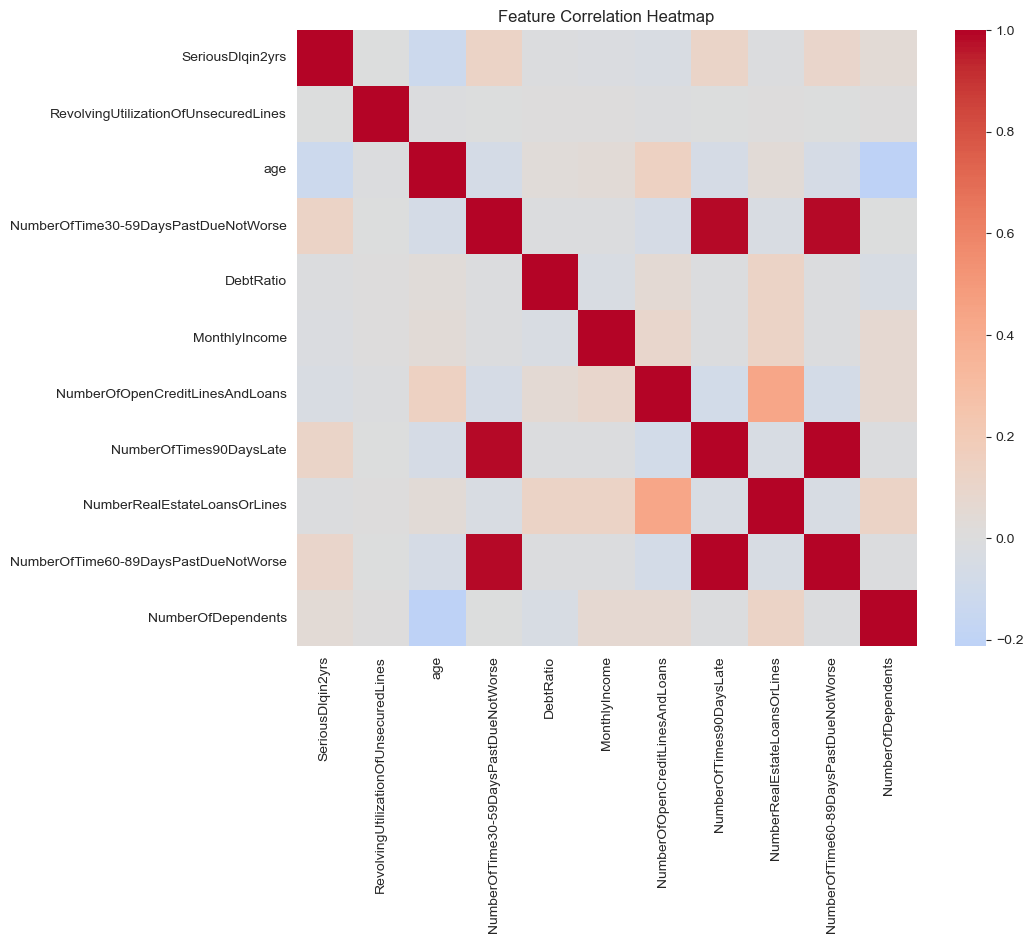

In [20]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()

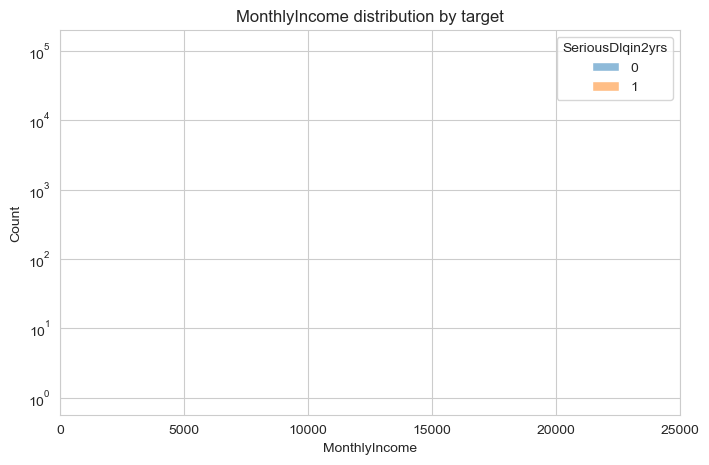

In [21]:
income_col = [c for c in df.columns if 'income' in c.lower()]
if income_col:
    col = income_col[0]
    plt.figure()
    sns.histplot(data=df, x=col, hue=TARGET_COL, bins=50, log_scale=(False, True))
    plt.xlim(0, df[col].quantile(0.99))
    plt.title(f'{col} distribution by target')
    plt.show()

In [22]:
def safe_col(name):
    return name if name in df.columns else None

# Common "Give Me Some Credit" column names
c_util   = safe_col('RevolvingUtilizationOfUnsecuredLines')
c_age    = safe_col('age')
c_debt   = safe_col('DebtRatio')
c_income = safe_col('MonthlyIncome')
c_lines  = safe_col('NumberOfOpenCreditLinesAndLoans')
c_dep    = safe_col('NumberOfDependents')
c_late30 = safe_col('NumberOfTime30-59DaysPastDueNotWorse')
c_late60 = safe_col('NumberOfTime60-89DaysPastDueNotWorse')
c_late90 = safe_col('NumberOfTimes90DaysLate')
c_re     = safe_col('NumberRealEstateLoansOrLines')

fe = df.copy()

# Total historical delinquencies -- a strong risk signal
late_cols = [c for c in [c_late30, c_late60, c_late90] if c]
if late_cols:
    fe['TotalTimesLate'] = fe[late_cols].sum(axis=1)
    fe['HasEverBeenLate'] = (fe['TotalTimesLate'] > 0).astype(int)

# Income-based ratios
if c_income and c_debt:
    fe['EstimatedMonthlyDebt'] = fe[c_debt] * fe[c_income].replace(0, np.nan)
if c_income and c_dep:
    fe['IncomePerDependent'] = fe[c_income] / (fe[c_dep] + 1)

# Credit line / real-estate mix
if c_lines and c_re:
    fe['NonRealEstateLines'] = fe[c_lines] - fe[c_re]

# Utilization bands (behavior tends to be nonlinear here)
if c_util:
    fe['HighUtilization'] = (fe[c_util] > 1.0).astype(int)  # data quirk: some rows exceed 1.0

print(f"Feature set grew from {df.shape[1]} to {fe.shape[1]} columns")
fe.head()


Feature set grew from 11 to 17 columns


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,TotalTimesLate,HasEverBeenLate,EstimatedMonthlyDebt,IncomePerDependent,NonRealEstateLines,HighUtilization
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,2,1,7323.197016,3040.0,7,0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,0,0,316.878123,1300.0,4,0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,2,1,258.914887,3042.0,2,0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,0,0,118.963951,3300.0,5,0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,1,1,1584.975094,63588.0,6,0


In [23]:
X = fe.drop(columns=[TARGET_COL])
y = fe[TARGET_COL]

# Keep numeric columns only for this baseline pipeline
X = X.select_dtypes(include=[np.number])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imp), columns=X_test.columns, index=X_test.index)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train class balance:\n{y_train.value_counts(normalize=True)}")


Train shape: (120000, 16), Test shape: (30000, 16)
Train class balance:
SeriousDlqin2yrs
0    0.933158
1    0.066842
Name: proportion, dtype: float64


In [24]:
models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
                             X_train_scaled, X_test_scaled),
    'Decision Tree': (DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=RANDOM_STATE),
                       X_train_imp, X_test_imp),
    'Random Forest': (RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced',
                                              random_state=RANDOM_STATE, n_jobs=-1),
                       X_train_imp, X_test_imp),
}

trained = {}
for name, (model, Xtr, Xte) in models.items():
    model.fit(Xtr, y_train)
    trained[name] = (model, Xte)
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: Decision Tree
Trained: Random Forest


In [26]:
results = []
roc_data = {}

for name, (model, Xte) in trained.items():
    y_pred = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
    })

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr)

results_df = pd.DataFrame(results).set_index('Model').sort_values('ROC-AUC', ascending=False)
results_df.round(4)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Random Forest,0.8359,0.2484,0.7182,0.3691,0.8654
Decision Tree,0.7992,0.2157,0.7601,0.3360,0.8537
Logistic Regression,0.8179,0.2237,0.6983,0.3388,0.8259


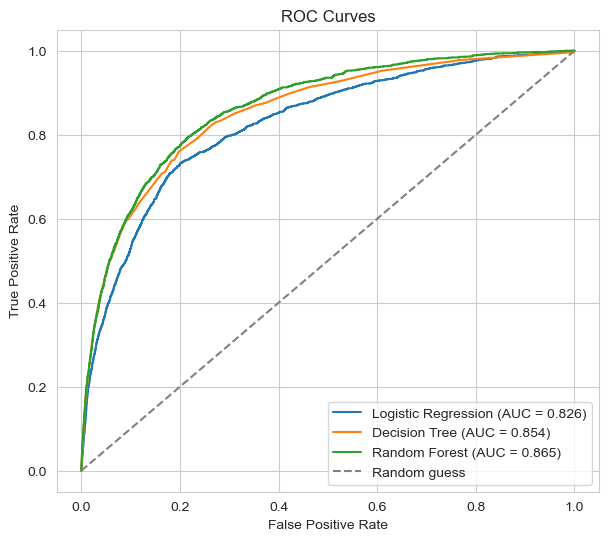

In [27]:
plt.figure(figsize=(7, 6))
for name, (fpr, tpr) in roc_data.items():
    auc = results_df.loc[name, 'ROC-AUC']
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

Best model by ROC-AUC: Random Forest


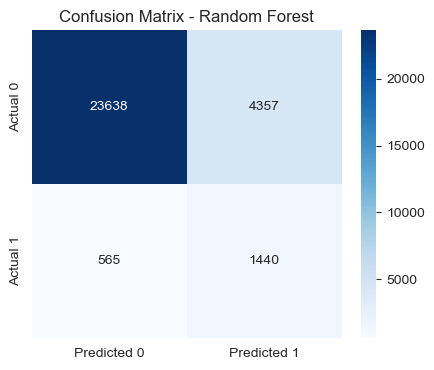

              precision    recall  f1-score   support

           0       0.98      0.84      0.91     27995
           1       0.25      0.72      0.37      2005

    accuracy                           0.84     30000
   macro avg       0.61      0.78      0.64     30000
weighted avg       0.93      0.84      0.87     30000



In [28]:
best_model_name = results_df['ROC-AUC'].idxmax()
best_model, best_Xte = trained[best_model_name]
print(f"Best model by ROC-AUC: {best_model_name}")

y_pred_best = best_model.predict(best_Xte)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

print(classification_report(y_test, y_pred_best))


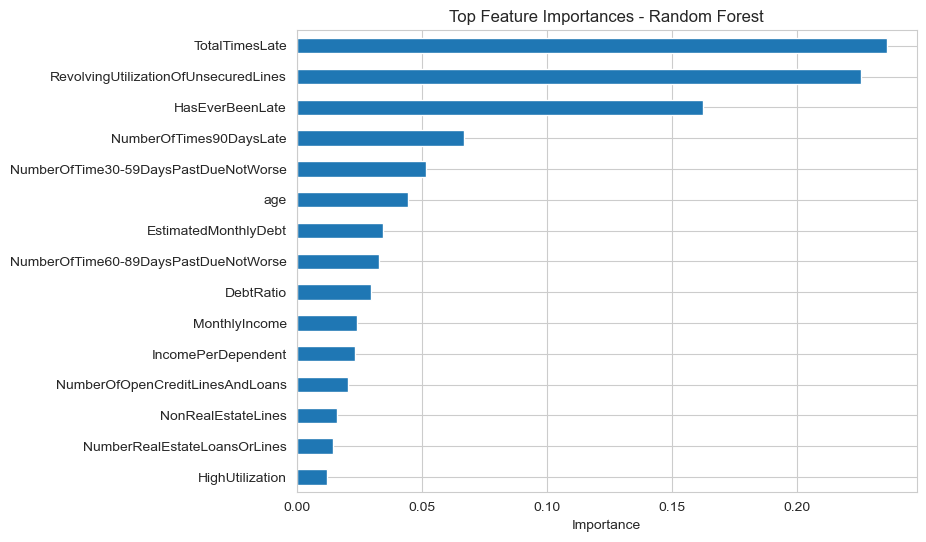

In [29]:
 # Feature importance (tree-based models only)
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=best_Xte.columns)
    importances = importances.sort_values(ascending=False).head(15)

    plt.figure(figsize=(8, 6))
    importances.sort_values().plot(kind='barh')
    plt.title(f'Top Feature Importances - {best_model_name}')
    plt.xlabel('Importance')
    plt.show()
elif hasattr(best_model, 'coef_'):
    coefs = pd.Series(best_model.coef_[0], index=best_Xte.columns)
    coefs = coefs.sort_values()

    plt.figure(figsize=(8, 6))
    coefs.plot(kind='barh')
    plt.title(f'Logistic Regression Coefficients - {best_model_name}')
    plt.xlabel('Coefficient (standardized features)')
    plt.show()


In [30]:
import os
os.makedirs('../models', exist_ok=True)

joblib.dump(best_model, f'../models/best_model_{best_model_name.replace(" ", "_").lower()}.pkl')
joblib.dump(imputer, '../models/imputer.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print(f"Saved best model ({best_model_name}) and preprocessing objects to ../models/")


Saved best model (Random Forest) and preprocessing objects to ../models/
